# Complete GAM guide

This notebook is a theory-first reference to NAMpy's statistical GAM
backend. It covers the formula and array interfaces, smooth construction,
structured effects, shape constraints, response families, smoothness
selection, inference, diagnostics, and multi-parameter GAMLSS models.
Related bases share compact galleries; representative models are fitted
rather than repeating identical boilerplate for every code.


## 1. Penalized regression splines

For response $y_i$ and conditional mean $\mu_i$, a GAM uses

$$g(\mu_i)=\mathbf x_i^\top\boldsymbol\gamma+
\sum_j\mathbf B_j(x_{ij})^\top\boldsymbol\beta_j+o_i.$$

Each basis dimension $K_j$ is finite. Smoothness is controlled by
$\lambda_j\boldsymbol\beta_j^\top\mathbf S_j\boldsymbol\beta_j$,
not by selecting a single polynomial degree. Large $K_j$ supplies
capacity; large $\lambda_j$ suppresses wiggliness. Side conditions remove
overlap between smooth null spaces, the intercept, and other terms.

Effective degrees of freedom summarize the flexibility remaining after
penalization. They are generally non-integer. Covariance and confidence
bands are conditional on the fitted model; optional unconditional
covariance also propagates estimated smoothing-parameter uncertainty.


## 2. Data and execution configuration


In [1]:
from pathlib import Path
import tempfile
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

FAST_MODE = True
N_SAMPLES = 160 if FAST_MODE else 5000
MAX_EPOCHS = 2 if FAST_MODE else 150
MAX_STEPS = 2 if FAST_MODE else -1
RANDOM_STATE = 7
CHECKPOINT_ROOT = Path(tempfile.mkdtemp(prefix="nampy-notebook-"))

NEURAL_FIT_KWARGS = {
    "max_epochs": MAX_EPOCHS,
    "max_steps": MAX_STEPS,
    "batch_size": 64 if FAST_MODE else 256,
    "random_state": RANDOM_STATE,
    "checkpoint_path": CHECKPOINT_ROOT,
    "logger": False,
    "enable_progress_bar": False,
    "enable_model_summary": False,
    "num_sanity_val_steps": 0,
}

rng = np.random.default_rng(RANDOM_STATE)

n = N_SAMPLES + (80 if FAST_MODE else 0)
x1 = rng.uniform(0.0, 1.0, n)
x2 = rng.uniform(-1.0, 1.0, n)
season = rng.uniform(0.0, 24.0, n)
group = pd.Categorical(rng.choice(["a", "b", "c", "d"], size=n))
group_effect = pd.Series(group).map({"a": -0.5, "b": 0.2, "c": 0.8, "d": -0.1}).astype(float).to_numpy()
surface = 0.9 * np.sin(np.pi * x1) * np.cos(np.pi * x2)
mu = 1.2 + np.sin(2 * np.pi * x1) + 0.35 * x2 + surface + group_effect
exposure = rng.uniform(0.5, 2.5, n)

data = pd.DataFrame({
    "x1": x1, "x2": x2, "season": season, "group": group,
    "exposure": exposure, "log_exposure": np.log(exposure),
})
data["y"] = mu + rng.normal(0.0, 0.25, n)
data["binary"] = rng.binomial(1, 1 / (1 + np.exp(-(-0.5 + mu))))
rate = np.exp(0.2 + 0.7 * np.sin(2 * np.pi * x1)) * exposure
data["count"] = rng.poisson(rate)
data["gamma"] = rng.gamma(shape=6.0, scale=np.exp(0.4 + 0.4 * x1) / 6.0)
data["beta"] = np.clip(rng.beta(2.0 + 2.0 * x1, 3.0), 1e-5, 1 - 1e-5)
data["ordinal"] = pd.cut(mu, bins=[-np.inf, 0.8, 1.6, 2.4, np.inf], labels=False) + 1
data["positive"] = np.maximum(0.0, rng.gamma(2.0, 0.5, n) - 0.35)

sigma = np.exp(-1.3 + 0.7 * (x2 + 1) / 2)
data["hetero"] = 1.0 + np.sin(2 * np.pi * x1) + sigma * rng.normal(size=n)
data["gamma_lss"] = rng.gamma(shape=1 / 0.25**2, scale=np.exp(0.2 + 0.5 * x1) * 0.25**2)
data.head()


,x1,x2,season,group,exposure,log_exposure,y,binary,count,gamma,beta,ordinal,positive,hetero,gamma_lss
0,0.625095,-0.241361,7.023409,a,0.568153,-0.565364,0.727774,0,0,1.324666,0.456304,1,2.700527,0.529906,1.703753
1,0.897214,-0.494451,7.030132,a,1.308638,0.268987,-0.163390,0,0,4.075249,0.610358,1,1.017491,0.728242,2.290064
2,0.775686,-0.086980,10.337878,d,1.655917,0.504355,0.364507,0,1,1.192106,0.764845,1,0.190409,-0.136088,1.697323
3,0.225207,0.314488,23.977410,d,1.006837,0.006814,2.132462,1,3,2.455830,0.257287,4,0.053814,2.009079,1.590799
4,0.300166,-0.797802,8.461247,c,1.196430,0.179342,1.910444,1,7,1.820847,0.118092,3,0.000000,1.535253,1.413327


## 3. Formula and array interfaces

Formula mode preserves named parametric terms, categorical contrasts,
smooth specifications, offsets, and multi-predictor formulas. Array mode
is compact and sklearn-friendly: each input column receives the adapter's
common basis and dimension. Use formula mode when terms need different
bases or structured effects.


In [2]:
from nampy.gam import GAM
from nampy.models import GAMClassifier, GAMLSS, GAMRegressor

formula_gam = GAM(
    formula="y ~ x2 + group + s(x1, bs='cr', k=10) + s(season, bs='cc', k=8)",
    family="gaussian",
    smoothing_method="reml",
).fit(data=data)

array_gam = GAMRegressor(k=9, basis="cr", smoothing_method="reml").fit(
    data[["x1", "x2"]], data["y"]
)

formula_prediction, formula_se = formula_gam.predict(data, type="response", return_se=True)
array_prediction = array_gam.predict(data[["x1", "x2"]])
display(formula_gam.summary())
display(pd.DataFrame({
    "interface": ["formula", "array"],
    "prediction shape": [formula_prediction.shape, array_prediction.shape],
    "intercept": [
        formula_gam.fit_result(include_covariances=False).intercept,
        array_gam.gam_.fit_result(include_covariances=False).intercept,
    ],
}))



Family: gaussian
Link function: identity

Formula:
y ~ x2 + group + s(x1, bs='cr', k=10) + s(season, bs='cc', k=8)

Parametric coefficients:
                 Estimate   Std. Error      t value     Pr(>|t|)    
(Intercept)       0.57777     0.067378       8.5751    1.755e-15 ***
x2                0.46828     0.060159       7.7841    2.695e-13 ***
group[b]          0.82721     0.090211       9.1697       <2e-16 ***
group[c]           1.4158     0.098073       14.437       <2e-16 ***
group[d]          0.49269     0.092823       5.3079    2.698e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                      edf       Ref.df            F      p-value    
s(x1)              8.6333       8.9604       45.441       <2e-16 ***
s(season)          5.7548            6      0.52101       0.7743  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.748   Deviance explained = 76.7%
Scale est. = 

GAMSummary(family_name='gaussian', link_name='identity', formula="y ~ x2 + group + s(x1, bs='cr', k=10) + s(season, bs='cc', k=8)", p_coeff=array([0.57777364, 0.46828359, 0.82720639, 1.41583613, 0.49269182]), se=array([0.06737768, 0.06015866, 0.09021103, 0.09807328, 0.09282286,
       0.13672281, 0.10398695, 0.11323893, 0.11334642, 0.10387469,
       0.10838754, 0.10649807, 0.11042186, 0.20266329, 0.0946373 ,
       0.08376293, 0.09210184, 0.0974602 , 0.08906054, 0.09600436]), p_t=array([ 8.57514851,  7.78414221,  9.16968137, 14.43651194,  5.30787134]), p_pv=array([1.75464297e-15, 2.69488344e-13, 3.43030093e-17, 1.05224197e-33,
       2.69755514e-07]), p_table=             Estimate  Std. Error    t value      Pr(>|t|)
(Intercept)  0.577774    0.067378   8.575149  1.754643e-15
x2           0.468284    0.060159   7.784142  2.694883e-13
group[b]     0.827206    0.090211   9.169681  3.430301e-17
group[c]     1.415836    0.098073  14.436512  1.052242e-33
group[d]     0.492692    0.092823   

,interface,prediction shape,intercept
0,formula,"(240,)",0.577774
1,array,"(240,)",1.260042


### 3.1 Prediction, uncertainty, offsets, and plots

`type="link"` predicts $\eta$; `type="response"` applies the inverse
link; `type="terms"` returns identified term contributions; and
`type="lpmatrix"` returns the design mapping coefficients to predictors.
Standard errors are pointwise, not simultaneous bands. An offset is
supplied in the formula with `offset(...)` or through the fit/predict
argument and is never estimated.


{'link shape': (240,),
 'lpmatrix shape': (240, 20),
 'offset AIC': 751.426753770295}

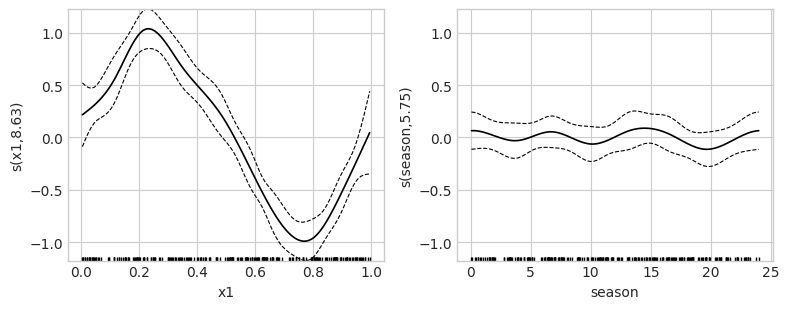

In [3]:
link = formula_gam.predict(data, type="link")
term_values = formula_gam.predict(data, type="terms", return_se=True)
Xp = formula_gam.lpmatrix(data)
formula_gam.plot(pages=1, se=True)

offset_gam = GAM(
    formula="count ~ s(x1, bs='cr', k=8) + offset(log_exposure)",
    family="poisson",
    smoothing_method="ubre",
).fit(data=data)
display({"link shape": link.shape, "lpmatrix shape": Xp.shape, "offset AIC": offset_gam.aic()})


## 4. Formula language and smooth bases

Basis choice encodes geometry and boundary behavior. Shrinkage variants
add a penalty to the usual null space so an entire smooth can approach
zero. Tensor products are appropriate when predictors use different
units. Random and factor-specific smooths encode grouped structures.

The gallery is executable specification: constructing every object checks
that the installed parser recognizes the formula. Related bases share a
comparison row because their fitting workflow is identical.


In [4]:
formula_gallery = pd.DataFrame([
    ("B-spline derivatives", "bs", "y ~ s(x1, bs='bs', k=9, m=[3, 2])"),
    ("cubic regression", "cr / cs", "y ~ s(x1, bs='cr', k=9)"),
    ("cyclic cubic / P-spline", "cc / cp", "y ~ s(season, bs='cc', k=9)"),
    ("Duchon spline", "ds", "y ~ s(x1, x2, bs='ds', k=16)"),
    ("Gaussian-process smooth", "gp", "y ~ s(x1, x2, bs='gp', k=16)"),
    ("P-spline", "ps", "y ~ s(x1, bs='ps', k=9)"),
    ("spherical spline", "sos", "y ~ s(latitude, longitude, bs='sos', k=20)"),
    ("thin plate / shrinkage", "tp / ts", "y ~ s(x1, x2, bs='tp', k=16)"),
    ("Markov random field", "mrf", "y ~ s(region, bs='mrf', xt={'nb': neighbors})"),
    ("random effect", "re", "y ~ s(group, bs='re')"),
    ("factor-specific", "fs / sz", "y ~ s(group, x1, bs='fs', k=6, xt='cr')"),
    ("full tensor product", "te", "y ~ te(x1, x2, bs=['cr', 'ps'], k=[6, 6])"),
    ("pure tensor interaction", "ti", "y ~ s(x1) + s(x2) + ti(x1, x2, k=[6, 6])"),
], columns=["intended use", "basis", "formula"])

constructible = {
    row.basis: GAM(formula=row.formula)
    for row in formula_gallery.itertuples()
    if row.basis not in {"mrf", "sos"}
}
formula_gallery


,intended use,basis,formula
0,B-spline derivatives,bs,"y ~ s(x1, bs='bs', k=9, m=[3, 2])"
1,cubic regression,cr / cs,"y ~ s(x1, bs='cr', k=9)"
2,cyclic cubic / P-spline,cc / cp,"y ~ s(season, bs='cc', k=9)"
3,Duchon spline,ds,"y ~ s(x1, x2, bs='ds', k=16)"
4,Gaussian-process smooth,gp,"y ~ s(x1, x2, bs='gp', k=16)"
5,P-spline,ps,"y ~ s(x1, bs='ps', k=9)"
6,spherical spline,sos,"y ~ s(latitude, longitude, bs='sos', k=20)"
7,thin plate / shrinkage,tp / ts,"y ~ s(x1, x2, bs='tp', k=16)"
8,Markov random field,mrf,"y ~ s(region, bs='mrf', xt={'nb': neighbors})"
9,random effect,re,"y ~ s(group, bs='re')"


### 4.1 Parametric terms and smoothness sharing

Numeric and categorical parametric terms use ordinary model-matrix
columns. `x1:x2` is a parametric interaction. A shared `id=` pools basis
construction and smoothing parameters across compatible smooths.
`select=True` adds null-space selection penalties. `pc=` imposes a point
constraint such as $f(0)=0$. `sp=` fixes a term's smoothing parameter;
omitted values are selected when automatic smoothing is enabled.


In [5]:
language_examples = {
    "parametric": GAM(formula="y ~ x1 + group + x1:group"),
    "shared smoothing": GAM(formula="y ~ s(x1, bs='cr', id='shared') + s(x2, bs='cr', id='shared')"),
    "term selection": GAM(formula="y ~ s(x1, bs='ts', k=10)", select=True),
    "point constraint": GAM(formula="y ~ s(x1, bs='cr', k=10, pc=0.0)"),
    "fixed smoothing": GAM(formula="y ~ s(x1, bs='cr', k=10, sp=0.8)"),
}
sorted(language_examples)


['fixed smoothing',
 'parametric',
 'point constraint',
 'shared smoothing',
 'term selection']

## 5. Main effects, interactions, and grouped structure

A tensor interaction separates marginal trends from a residual surface.
Random effects use ridge penalties and partial pooling. Factor-specific
smooths allow a curve per group: `fs` applies per-level penalties, while
`sz` uses sum-to-zero constraints so deviations are interpreted around a
population curve. Shared smoothing parameters reduce the number of
hyperparameters when scientific reasoning supports common roughness.



Family: gaussian
Link function: identity

Formula:
y ~ s(x1, bs='cr', k=8) + s(x2, bs='cr', k=8) + ti(x1, x2, bs=['cr', 'cr'], k=[5, 5]) + s(group, bs='re')

Parametric coefficients:
                 Estimate   Std. Error      t value     Pr(>|t|)    
(Intercept)         1.278      0.12343       10.354       <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                      edf       Ref.df            F      p-value    
s(x1)               6.761       6.9734       243.51       <2e-16 ***
s(x2)              6.7869         6.98       107.01       <2e-16 ***
ti(x1, x2)         9.3244        11.87       11.856       <2e-16 ***
s(group)           2.9441            3       268.33       <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.937   Deviance explained = 94.4%
Scale est. = 0.05987  n = 240


GAMSummary(family_name='gaussian', link_name='identity', formula="y ~ s(x1, bs='cr', k=8) + s(x2, bs='cr', k=8) + ti(x1, x2, bs=['cr', 'cr'], k=[5, 5]) + s(group, bs='re')", p_coeff=array([1.27803136]), se=array([0.12343228, 0.0596042 , 0.0492317 , 0.05392305, 0.04801951,
       0.05736465, 0.05301277, 0.09800791, 0.06714869, 0.0530108 ,
       0.05762367, 0.05331075, 0.05240847, 0.05696552, 0.09958005,
       0.11101136, 0.09211787, 0.10355703, 0.14315713, 0.11146588,
       0.08365471, 0.09902281, 0.1507523 , 0.11045715, 0.09040988,
       0.1028485 , 0.15820211, 0.12809775, 0.12631614, 0.12897461,
       0.2259239 , 0.12592877, 0.12521253, 0.12615619, 0.12555125]), p_t=array([10.35410989]), p_pv=array([1.29393191e-20]), p_table=             Estimate  Std. Error   t value      Pr(>|t|)
(Intercept)  1.278031    0.123432  10.35411  1.293932e-20, pterms_table=Empty DataFrame
Columns: [label, df, wald_stat, p_value, test, covariance, dispersion]
Index: [], s_table=        label       edf

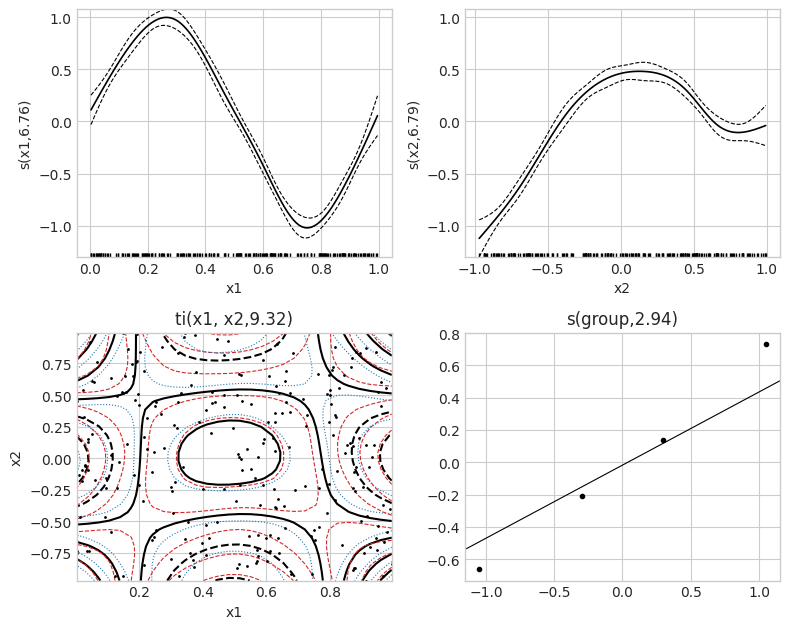

In [6]:
structured = GAM(
    formula=(
        "y ~ s(x1, bs='cr', k=8) + s(x2, bs='cr', k=8) "
        "+ ti(x1, x2, bs=['cr', 'cr'], k=[5, 5]) + s(group, bs='re')"
    ),
    family="gaussian",
    smoothing_method="reml",
).fit(data=data)

structured_terms = structured.predict(data, type="terms")
structured.plot(pages=1, se=True, n2=30)
display(structured.summary())


### 5.1 Periodic, spatial, and spherical effects

Cyclic bases identify the endpoints of a known period. MRF smooths couple
adjacent regions through a graph Laplacian and require a neighbor graph,
polygons, or a supplied penalty. Spherical splines treat latitude and
longitude as coordinates on a sphere; ordinary planar smooths can distort
global geometry. These compact objects document the required formulas
without inventing a large external map dataset.


In [7]:
cyclic = GAM(formula="y ~ s(season, bs='cc', k=10)", smoothing_method="reml").fit(data=data)
neighbors = {"north": ["central"], "central": ["north", "south"], "south": ["central"]}
spatial = GAM(formula="y ~ s(region, bs='mrf', xt={'nb': neighbors})")
spherical = GAM(formula="y ~ s(latitude, longitude, bs='sos', k=20)")

grid = pd.DataFrame({"season": np.linspace(0, 24, 200)})
cycle = cyclic.predict(grid)
display({"endpoint difference": float(abs(cycle[0] - cycle[-1])), "spatial formula": spatial.formula})


{'endpoint difference': 0.002638384650427872,
 'spatial formula': "y ~ s(region, bs='mrf', xt={'nb': neighbors})"}

## 6. Shape-constrained additive models

Shape constraints encode qualitative prior knowledge in the coefficient
parameterization. They are not post-fit clipping. First derivatives test
monotonicity; second derivatives test curvature. Positivity and anchoring
constrain function levels. Numeric-by and local bases apply restrictions
to varying-coefficient or subdomain effects. Bivariate codes constrain
directions or curvature of surfaces.


In [8]:
shape_reference = pd.DataFrame([
    ("mpi", "monotone increasing"), ("mpd", "monotone decreasing"),
    ("cx", "convex"), ("cv", "concave"),
    ("micx", "increasing and convex"), ("micv", "increasing and concave"),
    ("mdcx", "decreasing and convex"), ("mdcv", "decreasing and concave"),
    ("po", "positive"), ("ipo", "increasing positive"), ("dpo", "decreasing positive"),
    ("miso", "anchored increasing"), ("mifo", "anchored decreasing"),
    ("mpiby / mpdby", "numeric-by monotonicity"),
    ("cxby / cvby / micxby / micvby / mdcxby / mdcvby", "numeric-by curvature"),
    ("lmpi / lipl", "local constraints"), ("cpop", "locally positive cyclic effect"),
    ("tedmi / tedmd", "tensor monotonicity"),
    ("temicx / temicv / tedecx / tedecv", "tensor monotonicity plus curvature"),
    ("tecxcx / tecvcv / tecxcv", "bivariate curvature"),
    ("tesmi1 / tesmd1 / tesmi2 / tesmd2", "single-direction monotonicity"),
    ("tismi / tismd", "tensor-interaction monotonicity"),
    ("tescx / tescv", "single-direction curvature"),
], columns=["basis code", "mathematical property"])
shape_reference


,basis code,mathematical property
0,mpi,monotone increasing
1,mpd,monotone decreasing
2,cx,convex
3,cv,concave
4,micx,increasing and convex
5,micv,increasing and concave
6,mdcx,decreasing and convex
7,mdcv,decreasing and concave
8,po,positive
9,ipo,increasing positive


In [9]:
shape_data = pd.DataFrame({"x": np.linspace(0, 1, n)})
shape_data["increasing"] = 1 + 3 * (1 - np.exp(-4 * shape_data["x"])) + rng.normal(0, 0.08, n)
shape_data["convex"] = 0.5 + 2.0 * shape_data["x"]**2 + rng.normal(0, 0.06, n)

monotone = GAM(
    formula="increasing ~ s(x, bs='mpi', k=10)",
    optimize_smoothing=False, smoothing_method="fixed", smoothing_params=[0.5],
).fit(data=shape_data)
convex = GAM(
    formula="convex ~ s(x, bs='cx', k=10)",
    optimize_smoothing=False, smoothing_method="fixed", smoothing_params=[0.5],
).fit(data=shape_data)

d1 = monotone.derivative(smooth_number=1, deriv=1).derivative
d2 = convex.derivative(smooth_number=1, deriv=2).derivative
assert d1.min() >= -1e-6
assert d2.min() >= -1e-6
display({"minimum first derivative": d1.min(), "minimum second derivative": d2.min()})


{'minimum first derivative': 0.34771668790873866,
 'minimum second derivative': 0.0}

## 7. Response families and links

The family determines support, variance, likelihood, deviance, residuals,
and inverse-link interpretation. The same smooth formula is therefore not
a substitute for choosing a scientifically appropriate distribution.
The examples below simulate responses on the required support and report
one family-appropriate check.


In [10]:
family_specs = {
    "Gaussian": ("y", "gaussian", "y ~ s(x1, bs='cr', k=8) + x2"),
    "Binomial": ("binary", "binomial", "binary ~ s(x1, bs='cr', k=8) + x2"),
    "Poisson": ("count", "poisson", "count ~ s(x1, bs='cr', k=8) + offset(log_exposure)"),
    "Gamma": ("gamma", {"name": "gamma", "link": "log"}, "gamma ~ s(x1, bs='cr', k=8)"),
    "Negative binomial": ("count", {"name": "nb"}, "count ~ s(x1, bs='cr', k=8) + offset(log_exposure)"),
    "Beta": ("beta", {"name": "betar", "theta": 8.0}, "beta ~ s(x1, bs='cr', k=8)"),
    "Tweedie": ("positive", {"name": "tweedie", "link": "log"}, "positive ~ s(x1, bs='cr', k=8)"),
    "Ordered categorical": ("ordinal", {"name": "ocat", "R": 4}, "ordinal ~ s(x1, bs='cr', k=8)"),
}

family_rows = []
family_models = {}
for label, (target, family, formula) in family_specs.items():
    method = "ubre" if label == "Poisson" else "reml"
    candidate = GAM(formula=formula, family=family, smoothing_method=method).fit(data=data)
    family_models[label] = candidate
    fitted = np.asarray(candidate.predict(data, type="response"))
    family_rows.append({
        "family": label,
        "finite predictions": bool(np.isfinite(fitted).all()),
        "prediction minimum": float(np.min(fitted)),
        "deviance residual RMS": float(np.sqrt(np.mean(candidate.residuals(type="deviance")**2))),
    })
pd.DataFrame(family_rows)


,family,finite predictions,prediction minimum,deviance residual RMS
0,Gaussian,True,-0.058786,0.669675
1,Binomial,True,0.338648,1.065651
2,Poisson,True,0.389765,0.994880
3,Gamma,True,1.448257,0.386918
4,Negative binomial,True,0.389765,0.994877
5,Beta,True,0.331917,1.098874
6,Tweedie,True,0.472319,1.066770
7,Ordered categorical,True,0.014442,1.443130


## 8. Selecting smoothness

Fixed smoothing is useful for controlled comparisons. GCV/Cp and UBRE
estimate predictive risk; ML, REML, and LAML use marginal-likelihood
criteria. REML is a strong default for many ordinary GAMs. Outer Newton
uses derivatives, BFGS is quasi-Newton, EFS is extended Fellner-Schall,
and the `optim` route can use methods such as L-BFGS-B where supported.
Availability depends jointly on family, criterion, and optimizer.


In [11]:
smoothness_routes = [
    ("fixed", False, "fixed", "outer_newton", None),
    ("GCV/Cp", True, "gcv", "outer_newton", None),
    ("REML Newton", True, "reml", "outer_newton", None),
    ("REML BFGS", True, "reml", "bfgs", None),
    ("REML EFS", True, "reml", "efs", None),
    ("REML optim/L-BFGS-B", True, "reml", "optim", "L-BFGS-B"),
]

selection_rows = []
for label, optimize, method, optimizer, optim_method in smoothness_routes:
    started = time.perf_counter()
    kwargs = dict(
        formula="y ~ s(x1, bs='cr', k=10)", family="gaussian",
        optimize_smoothing=optimize, smoothing_method=method,
        smoothing_optimizer=optimizer,
    )
    if not optimize:
        kwargs["smoothing_params"] = [0.7]
    if optim_method is not None:
        kwargs["optim_method"] = optim_method
    candidate = GAM(**kwargs).fit(data=data)
    result = candidate.fit_result(include_covariances=False)
    selection_rows.append({
        "route": label,
        "fit seconds": time.perf_counter() - started,
        "EDF": result.edf_total,
        "criterion": result.criterion_value,
        "smoothing parameter": result.smoothing_params[0],
    })
selection_table = pd.DataFrame(selection_rows)
selection_table


,route,fit seconds,EDF,criterion,smoothing parameter
0,fixed,0.124734,9.742437,NaN,0.700000
1,GCV/Cp,1.111831,5.732176,0.510515,84.806366
2,REML Newton,1.431619,6.502093,265.117973,41.129305
3,REML BFGS,3.034044,6.502080,265.117973,41.129803
4,REML EFS,1.098485,6.502086,265.117973,41.129562
5,REML optim/L-BFGS-B,2.788102,6.502076,265.117973,41.129942


## 9. Inference and diagnostics

Confidence bands describe estimated-function uncertainty under the model;
residual plots examine distributional assumptions; derivatives describe
rates of change. ANOVA compares nested models when its assumptions apply.
AIC/BIC and log likelihood compare fit against complexity. Concurvity is
the smooth analogue of collinearity. `k_check` asks whether a chosen basis
dimension leaves residual pattern, and `gam_check` combines comparable
residual and basis-dimension checks with local optimizer information.


In [12]:
good = GAM(formula="y ~ s(x1, bs='cr', k=12) + s(x2, bs='cr', k=9)", smoothing_method="reml").fit(data=data)
poor = GAM(formula="y ~ s(x1, bs='cr', k=4)", smoothing_method="reml").fit(data=data)

diagnostic_report = {
    "log likelihood": good.loglik(),
    "AIC": good.aic(),
    "BIC": good.bic(),
    "covariance shape": good.vcov().shape,
    "residual RMS": float(np.sqrt(np.mean(good.residuals(type="deviance")**2))),
}
poor_k = poor.k_check(subsample=min(len(data), 200), n_rep=20, seed=RANDOM_STATE)
poor_check = poor.gam_check(k_sample=min(len(data), 200), k_rep=20, seed=RANDOM_STATE)
concurvity = good.concurvity()
anova_table = poor.anova(good, test="F")
display(diagnostic_report)
display(poor_k)
display(anova_table)


{'log likelihood': -199.21799895773694,
 'AIC': 438.8981847576252,
 'BIC': 509.31531598078925,
 'covariance shape': (20, 20),
 'residual RMS': 0.5549576149855296}

,k_prime,edf,k_index,p_value
label,,,,
s(x1),3,2.954146,0.952995,0.15


AnovaGAMComparison(family_name='gaussian', test='F', table=    Resid. Df  Resid. Dev         Df   Deviance         F        Pr(>F)
0  236.001672  117.437395        NaN        NaN       NaN           NaN
1  220.089306   73.914709  15.912366  43.522686  8.169359  3.289948e-15)

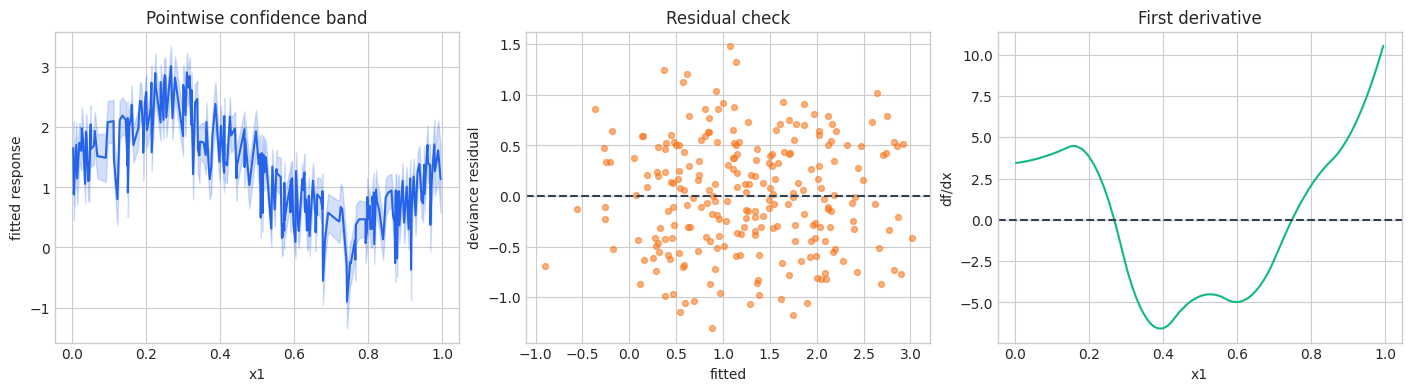

In [13]:
prediction, se = good.predict(data, type="response", return_se=True)
derivative_model = GAM(
    formula="y ~ s(x1, bs='ps', k=10)",
    optimize_smoothing=False,
    smoothing_method="fixed",
    smoothing_params=[0.7],
).fit(data=data)
derivative = derivative_model.derivative(data, smooth_number=1, deriv=1)
order = np.argsort(data["x1"].to_numpy())

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
axes[0].plot(data["x1"].to_numpy()[order], prediction[order], color=COLORS[0])
axes[0].fill_between(data["x1"].to_numpy()[order], (prediction - 2*se)[order], (prediction + 2*se)[order], color=COLORS[0], alpha=0.2)
axes[0].set(title="Pointwise confidence band", xlabel="x1", ylabel="fitted response")
axes[1].scatter(prediction, good.residuals(type="deviance"), s=18, alpha=0.55, color=COLORS[1])
axes[1].axhline(0, color="#334155", linestyle="--")
axes[1].set(title="Residual check", xlabel="fitted", ylabel="deviance residual")
axes[2].plot(data["x1"].to_numpy()[order], derivative.derivative[order], color=COLORS[2])
axes[2].axhline(0, color="#334155", linestyle="--")
axes[2].set(title="First derivative", xlabel="x1", ylabel="df/dx")
plt.show()
plt.close(fig)


## 10. Distributional GAMs

A GAMLSS model assigns one additive predictor to every distribution
parameter. For a normal model,

$$Y_i\mid x_i,z_i\sim N\{\mu(x_i),\sigma(z_i)^2\}.$$

Joint likelihood fitting differs from modeling squared residuals in a
second stage: location and scale are estimated together with their joint
covariance. Contributions reconstruct each raw parameter predictor.
Natural-parameter transforms then enforce domains such as $\sigma>0$.


In [14]:
normal_lss = GAMLSS(
    formula=[
        "hetero ~ s(x1, bs='cr', k=9)",
        "~ s(x2, bs='cr', k=8)",
    ],
    family="normal",
    smoothing_method="ml",
).fit(data)

natural = normal_lss.predict(data)
raw = normal_lss.predict(data, raw=True)
point = normal_lss.predict_point(data)
components = normal_lss.predict_components(data)
components.validate_additive_reconstruction()
parameter_importance = normal_lss.term_importance(data)

lower = natural[:, 0] - 1.96 * natural[:, 1]
upper = natural[:, 0] + 1.96 * natural[:, 1]
coverage = np.mean((data["hetero"] >= lower) & (data["hetero"] <= upper))
display({
    "parameter names": normal_lss.parameter_names_,
    "raw shape": raw.shape,
    "natural shape": natural.shape,
    "minimum sigma": natural[:, 1].min(),
    "95% interval coverage": coverage,
})
display(parameter_importance)


{'parameter names': ('mu', 'sigma'),
 'raw shape': (240, 2),
 'natural shape': (240, 2),
 'minimum sigma': 0.2881437585196322,
 '95% interval coverage': 0.9625}

,term,term_type,output,importance
0,"mu:s(x1, bs='cr', k=9)",interaction,0,0.641511
1,"sigma:s(x2, bs='cr', k=8)",interaction,1,0.111352
2,"mu:s(x1, bs='cr', k=9)",interaction,1,0.000000
3,"sigma:s(x2, bs='cr', k=8)",interaction,0,0.000000


### 10.1 Normal and Gamma location-scale models

`gaulss` returns natural $(\mu,\sigma)$ despite using a precision-related
scale predictor internally. `gammals` models a positive mean and scale;
both are transformed to remain positive. `predict(raw=True)` exposes the
additive predictors, `predict` returns natural parameters, and
`predict_point` returns the family-defined conditional mean.


In [15]:
gamma_lss = GAMLSS(
    formula=["gamma_lss ~ s(x1, bs='cr', k=8)", "~ 1"],
    family="gamma",
    smoothing_method="ml",
).fit(data)

gamma_parameters = gamma_lss.predict(data)
gamma_components = gamma_lss.predict_components(data)
gamma_components.validate_additive_reconstruction()
display({
    "normal NLL": normal_lss.evaluate(data, data["hetero"])["Negative Log-Likelihood"],
    "gamma NLL": gamma_lss.evaluate(data, data["gamma_lss"])["Negative Log-Likelihood"],
    "gamma parameters positive": bool((gamma_parameters > 0).all()),
})


{'normal NLL': 0.3957955326972089,
 'gamma NLL': 0.46935598007658114,
 'gamma parameters positive': True}

## 11. Practical model-building sequence

Start with the response support and link, then specify scientifically
justified main effects and structures. Give bases enough capacity, select
smoothness, and inspect residuals, `k_check`, concurvity, and sensitivity
to plausible basis choices. Add interactions or distributional parameters
only when they answer a substantive question. Finally validate on held-out
data and persist the complete fitted object.
